In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [16]:
df = pd.read_csv('data_science_job.csv',usecols=[2,8,11,12])

In [17]:
df.head()

,city_development_index,experience,training_hours,target
0,0.920,20.0,36.0,1.0
1,0.776,15.0,47.0,0.0
2,0.624,5.0,83.0,0.0
3,0.789,0.0,52.0,1.0
4,0.767,20.0,8.0,0.0


In [44]:
df.isnull().mean()*100

city_development_index    2.500261
experience                0.339284
training_hours            3.998330
target                    0.000000
dtype: float64

In [19]:
x = df.drop(columns=['target'])
y = df['target']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [21]:
mean_city_development_index = df['city_development_index'].mean()
median_city_development_index = df['city_development_index'].median()

mean_experience = df['experience'].mean()
median_experience = df['experience'].median()

mean_training_hours = df['training_hours'].mean()
median_training_hours = df['training_hours'].median()

In [24]:
x_train['mean_city_development_index'] = x_train['city_development_index'].fillna(mean_city_development_index)
x_train['median_city_development_index'] = x_train['city_development_index'].fillna(median_city_development_index)

x_train['mean_experience'] = x_train['experience'].fillna(mean_experience)
x_train['median_experience'] = x_train['experience'].fillna(median_experience)

x_train['mean_training_hours'] = x_train['training_hours'].fillna(mean_training_hours)
x_train['median_training_hours'] = x_train['training_hours'].fillna(median_training_hours)

In [43]:
x_train.sample(5)

,city_development_index,experience,training_hours,mean_city_development_index,median_city_development_index,mean_experience,median_experience,mean_training_hours,median_training_hours
4222,0.887,20.0,121.0,0.887,0.887,20.0,20.0,121.0,121.0
2856,0.920,6.0,111.0,0.920,0.920,6.0,6.0,111.0,111.0
14011,0.913,20.0,216.0,0.913,0.913,20.0,20.0,216.0,216.0
5222,0.624,4.0,48.0,0.624,0.624,4.0,4.0,48.0,48.0
360,0.910,20.0,38.0,0.910,0.910,20.0,20.0,38.0,38.0


In [47]:
print("original city_development_index Column Variance", x_train['city_development_index'].var())
print("city_development_index Column Variance After Mean Imputation", x_train['mean_city_development_index'].var())
print("city_development_index Column Variance After Median Imputation", x_train['median_city_development_index'].var())
print("")
print("original experience Column Variance", x_train['experience'].var())
print("experience Column Variance After Mean Imputation", x_train['mean_experience'].var())
print("experience Column Variance After Median Imputation", x_train['median_experience'].var())
print("")
print("original training_hours Column Variance", x_train['training_hours'].var())
print("training_hours Column Variance After Mean Imputation", x_train['mean_training_hours'].var())
print("training_hours Column Variance After Median Imputation", x_train['median_training_hours'].var())

original city_development_index Column Variance 0.015232596622262501
city_development_index Column Variance After Mean Imputation 0.01484395611848653
city_development_index Column Variance After Median Imputation 0.014981311927511435

original experience Column Variance 42.31272262041923
experience Column Variance After Mean Imputation 42.17743322586463
experience Column Variance After Median Imputation 42.180276296408245

original training_hours Column Variance 3605.7523453683752
training_hours Column Variance After Mean Imputation 3462.2281304539474
training_hours Column Variance After Median Imputation 3474.8349974528187


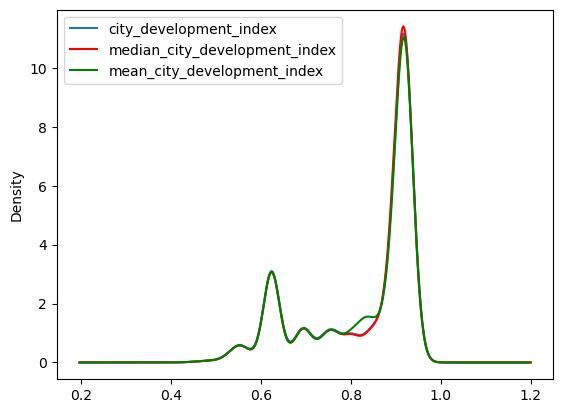

In [48]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['city_development_index'].plot(kind='kde', ax=ax)

# variable imputed with the median
x_train['median_city_development_index'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
x_train['mean_city_development_index'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

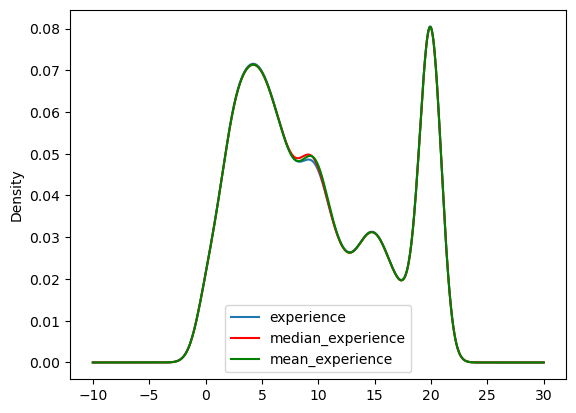

In [49]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['experience'].plot(kind='kde', ax=ax)

# variable imputed with the median
x_train['median_experience'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
x_train['mean_experience'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

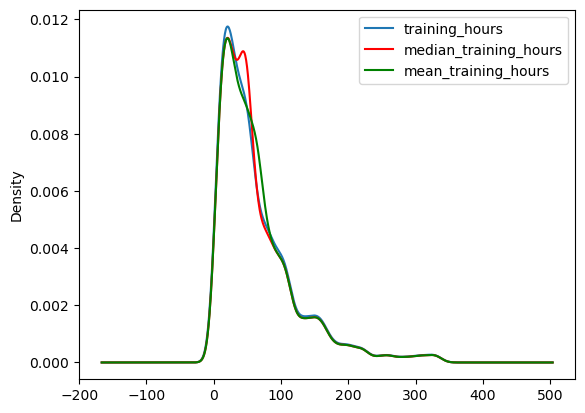

In [50]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['training_hours'].plot(kind='kde', ax=ax)

# variable imputed with the median
x_train['median_training_hours'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
x_train['mean_training_hours'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [51]:
x_train.cov()

,city_development_index,experience,training_hours,mean_city_development_index,median_city_development_index,mean_experience,median_experience,mean_training_hours,median_training_hours
city_development_index,0.015233,0.265945,0.045247,0.015233,0.015233,0.265093,0.265287,0.043447,0.049797
experience,0.265945,42.312723,0.923956,0.259156,0.259576,42.312723,42.312723,0.886332,1.096184
training_hours,0.045247,0.923956,3605.752345,0.044084,0.039276,0.919676,0.878605,3605.752345,3605.752345
mean_city_development_index,0.015233,0.259156,0.044084,0.014844,0.014844,0.258331,0.258520,0.042321,0.048511
median_city_development_index,0.015233,0.259576,0.039276,0.014844,0.014981,0.258749,0.258940,0.037704,0.044294
mean_experience,0.265093,42.312723,0.919676,0.258331,0.258749,42.177433,42.177482,0.882793,1.091956
median_experience,0.265287,42.312723,0.878605,0.258520,0.258940,42.177482,42.180276,0.843358,1.051474
mean_training_hours,0.043447,0.886332,3605.752345,0.042321,0.037704,0.882793,0.843358,3462.228130,3462.211456
median_training_hours,0.049797,1.096184,3605.752345,0.048511,0.044294,1.091956,1.051474,3462.211456,3474.834997


In [52]:
x_train.corr()

,city_development_index,experience,training_hours,mean_city_development_index,median_city_development_index,mean_experience,median_experience,mean_training_hours,median_training_hours
city_development_index,1.000000,0.331741,0.006114,1.000000,1.000000,0.330925,0.331157,0.005979,0.006840
experience,0.331741,1.000000,0.002366,0.327286,0.326315,1.000000,1.000000,0.002317,0.002860
training_hours,0.006114,0.002366,1.000000,0.006039,0.005356,0.002358,0.002252,1.000000,1.000000
mean_city_development_index,1.000000,0.327286,0.006039,1.000000,0.995440,0.326483,0.326712,0.005903,0.006755
median_city_development_index,1.000000,0.326315,0.005356,0.995440,1.000000,0.325510,0.325738,0.005235,0.006139
mean_experience,0.330925,1.000000,0.002358,0.326483,0.325510,1.000000,0.999967,0.002310,0.002852
median_experience,0.331157,1.000000,0.002252,0.326712,0.325738,0.999967,1.000000,0.002207,0.002746
mean_training_hours,0.005979,0.002317,1.000000,0.005903,0.005235,0.002310,0.002207,1.000000,0.998180
median_training_hours,0.006840,0.002860,1.000000,0.006755,0.006139,0.002852,0.002746,0.998180,1.000000


<Axes: >

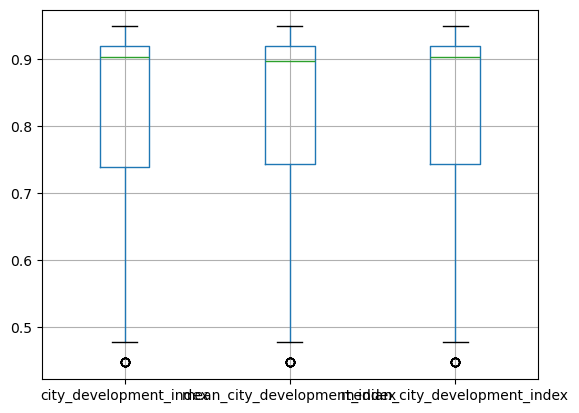

In [54]:
x_train[['city_development_index','mean_city_development_index','median_city_development_index']].boxplot()

<Axes: >

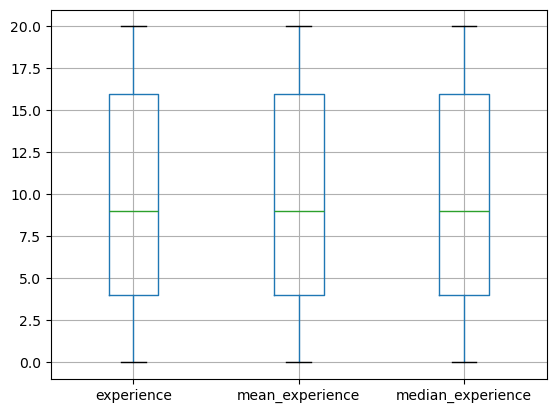

In [55]:
x_train[['experience','mean_experience','median_experience']].boxplot()

<Axes: >

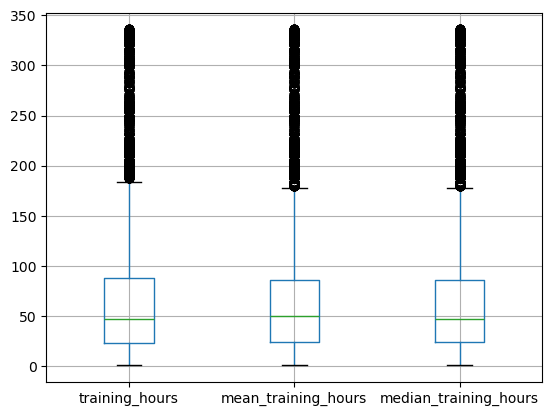

In [60]:
x_train[['training_hours','mean_training_hours','median_training_hours']].boxplot()

In [ ]:
# using Scikit Learn

In [61]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [62]:
imputer1 = SimpleImputer(strategy='mean')
imputer2 = SimpleImputer(strategy='median')

In [65]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['city_development_index']),
    ('imputer2',imputer2,['experience']),
    ('imputer3',imputer2,['training_hours'])
],remainder='passthrough')

In [66]:
trf.fit(x_train)

x_train = trf.transform(x_train)
x_test = trf.transform(x_test)

x_train

array([[  0.624,   2.   , 134.   ],
       [  0.92 ,   8.   ,  58.   ],
       [  0.92 ,   7.   , 206.   ],
       ...,
       [  0.92 ,  20.   , 120.   ],
       [  0.92 ,   7.   ,  48.   ],
       [  0.91 ,   4.   ,  74.   ]])

In [67]:
trf.named_transformers_['imputer1'].statistics_

array([0.82867238])

In [68]:
trf.named_transformers_['imputer2'].statistics_

array([9.])

In [69]:
trf.named_transformers_['imputer3'].statistics_

array([47.])